<a href="https://colab.research.google.com/github/ByteCrafty/Learning_Deep_Learning/blob/main/regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [6]:
X, y = make_moons(100, noise=0.25,random_state=2)
X,y

(array([[ 1.04051282e+00, -2.33491352e-02],
        [-5.54741398e-01,  1.27013832e+00],
        [-7.23715066e-02, -1.77901205e-01],
        [-4.71961272e-02,  1.21883595e+00],
        [ 9.13794475e-01,  8.59883240e-01],
        [ 5.41150127e-01,  6.95140255e-01],
        [ 7.03026094e-01, -2.57985072e-01],
        [-1.33401091e-01,  1.06959481e+00],
        [-1.14287718e-01,  8.97688273e-01],
        [ 1.01150903e+00,  8.49916582e-01],
        [ 2.12537198e+00,  5.08605794e-01],
        [ 1.70010780e+00,  7.16265767e-01],
        [ 1.55439712e+00, -8.60585592e-01],
        [ 5.55027808e-01,  5.76836247e-01],
        [ 1.15481964e+00, -1.43219905e-01],
        [ 2.86145607e-01,  1.32282616e+00],
        [ 4.89545211e-01,  2.91536879e-01],
        [-6.67796665e-01,  7.81730273e-01],
        [ 2.23453555e-01,  3.34602767e-02],
        [ 1.18698241e+00, -3.39029325e-01],
        [-6.08507947e-01,  4.54265298e-01],
        [ 8.29543872e-01,  7.39089646e-01],
        [ 1.13299058e+00, -2.622

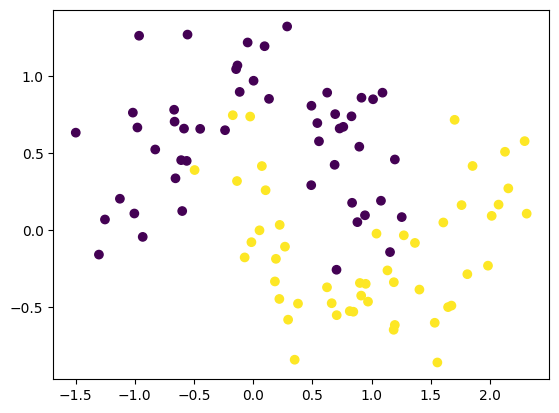

In [7]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [8]:
model1 = Sequential()

model1.add(Dense(128,input_dim=2, activation="relu"))
model1.add(Dense(128, activation="relu"))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
adam = Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history1 = model1.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


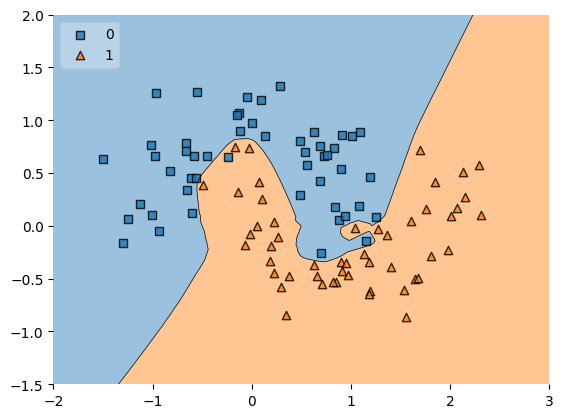

In [10]:
plot_decision_regions(X, y.astype('int'), clf=model1, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

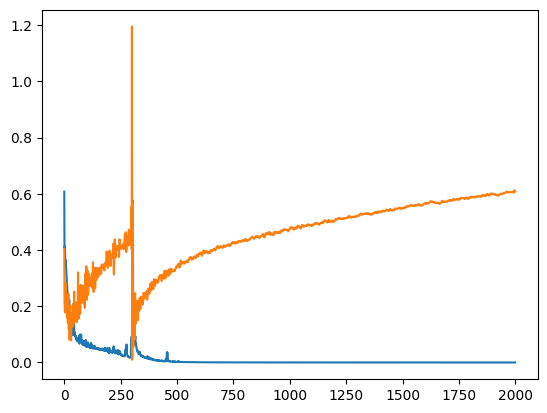

In [11]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

In [27]:
model2 = Sequential()

model2.add(Dense(128,input_dim=2, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.001)))
model2.add(Dense(128, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.001)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


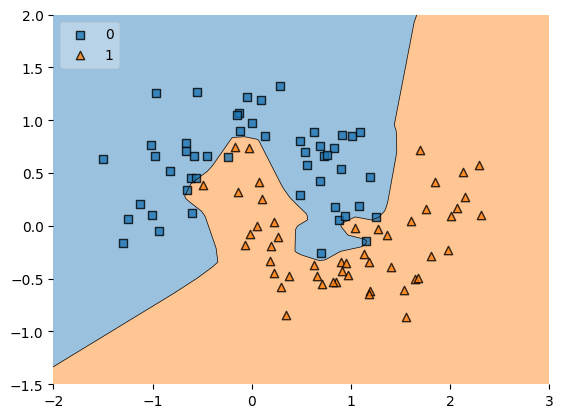

In [29]:
plot_decision_regions(X, y.astype('int'), clf=model2, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

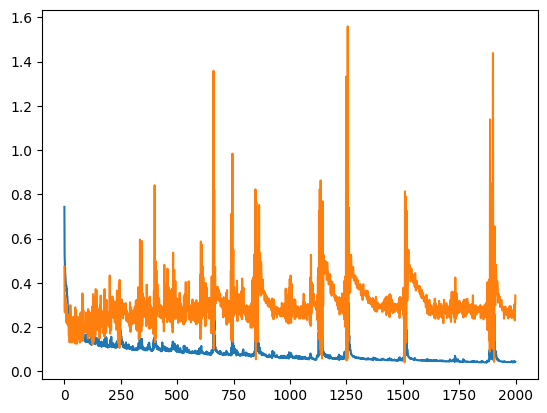

In [30]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [31]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

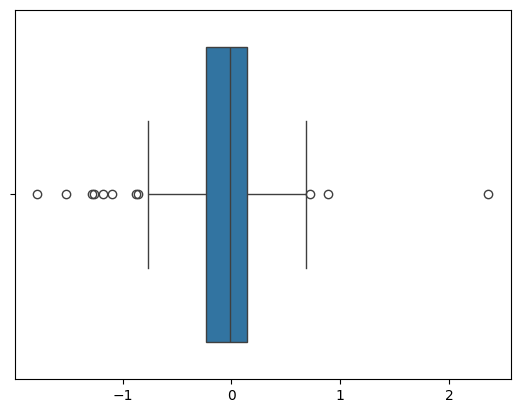

In [36]:
sns.boxplot(x=model1_weight_layer1)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

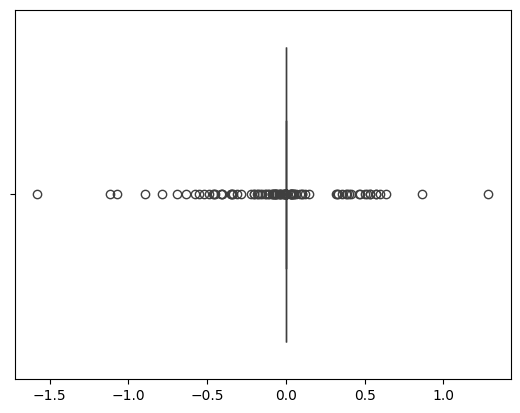

In [37]:
sns.boxplot(x = model2_weight_layer1)
plt.show

In [38]:
model1_weight_layer1.min()

np.float32(-1.784487)

In [39]:
model2_weight_layer1.min()

np.float32(-1.5770279)

In [ ]:
sns.histplot(model1_weight_layer1, kde=True, label='Model 1')
sns.histplot(model2_weight_layer1, kde=True, label='Model 2')

plt.legend()
plt.show()

In [26]:
model1.get_weights()[0].reshape(256)

array([ 6.76259160e-01,  7.69945607e-02, -4.12172586e-01, -7.30169833e-01,
       -5.21781016e-03,  3.92267674e-01, -2.72630662e-01, -4.55466449e-01,
       -4.76237208e-01, -4.36940014e-01,  3.46424520e-01, -4.61663693e-01,
       -4.63214703e-02, -4.46306229e-01,  8.91466141e-01, -4.54419963e-02,
        6.74280971e-02,  1.10050030e-02, -2.92595446e-01,  3.89513075e-01,
       -4.65990335e-01, -3.82458493e-02,  3.40041667e-01,  3.77287269e-01,
       -2.25281090e-01, -6.41801834e-01,  4.44050848e-01, -7.26078331e-01,
       -4.22920361e-02, -4.16698277e-01, -3.76158416e-01,  1.34435222e-01,
        4.18680221e-01, -1.14949644e-01, -5.32597959e-01,  1.45635977e-01,
        2.36495465e-01,  3.62034410e-01, -1.35907978e-01, -1.18230104e-01,
       -2.82420874e-01, -6.04865074e-01,  7.83990100e-02, -4.77381468e-01,
        3.56579065e-01,  3.47658107e-03, -7.08998084e-01, -3.39508593e-01,
        1.84715748e-01, -2.61402130e-01,  8.16332251e-02, -6.57898128e-01,
        2.63785601e-01, -